In [68]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

Autosaving every 300 seconds


In [69]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pylab import *
from time import time
from mpl_toolkits import mplot3d


In [70]:
# grille pour Dirichlet bord haut et droit.
# Neumann pour bord gauche et bas
# 
L=3
H=4
Nx=100
Ny=100
dx=L/(Nx)
dy=H/(Ny)
x=linspace(0,L-dx,Nx)
y=linspace(0,H-dy,Ny)

#liste des numéros des noeuds presentants 4 voisins faisant partie des noeuds où la solution est inconnue
Linterieur = []
for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        Linterieur.append(i + j*Nx)
        

#plt.xlim(0, L)
#plt.ylim(0, H)
#print(Linterieur)

#liste des noeuds du bas sauf coins
Lbas=[i for i in range(1,Nx-1)]
#liste des noeuds du haut sauf coins
Lhaut=[i for i in range(Nx*(Ny-1)+1,Nx*Ny-1)]
#liste des noeuds de gauche sauf coins
Lgauche=[i*Nx for i in range(1,Ny-1)]
#liste des noeuds de droite sauf coins
Ldroite=[i*Nx-1 for i in range(2,Ny)]


A=lil_matrix((Nx*Ny,Nx*Ny))
#construction de la diagonale de A
for k in range(Nx*Ny):
    A[k,k]=2/dx**2+2/dy**2
#construction de la matrice A pour les noeuds presentants 4 voisins inconnus
for k in Linterieur:
    A[k,k+1]=-1/dx**2
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-1/dy**2
    A[k,k-Nx]=-1/dy**2
# contribution pour les noeuds du bas
for k in Lbas:
    A[k,k+1]=-1/dx**2
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-2/dy**2
# contribution pour les noeuds du haut
for k in Lhaut:
    A[k,k+1]=-1/dx**2
    A[k,k-1]=-1/dx**2
    A[k,k-Nx]=-1/dy**2
# contribution pour les noeuds de gauche
for k in Lgauche:
    A[k,k+1]=-2/dx**2
    A[k,k+Nx]=-1/dy**2
    A[k,k-Nx]=-1/dy**2
# contribution pour les noeuds de droite
for k in Ldroite:
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-1/dy**2
    A[k,k-Nx]=-1/dy**2
#coin bas gauche
k=0
A[k,k+1]=-2/dx**2
A[k,k+Nx]=-2/dy**2
#coin bas droite
k=Nx-1
A[k,k-1]=-1/dx**2
A[k,k+Nx]=-2/dy**2
#coin haut gauche
k=Nx*(Ny-1)
A[k,k+1]=-2/dx**2
A[k,k-Nx]=-1/dy**2
#coin haut droite
k=Nx*Ny-1
A[k,k-1]=-1/dx**2
A[k,k-Nx]=-1/dy**2

A= csr_matrix(A)
#print(A.toarray())
#construction d'un second membre trivial
f=-ones(Nx*Ny)
#
#resolution du systeme lineaire creux
#
t=time()
u=spsolve(A,f)
t2=time()

#print(A.toarray())

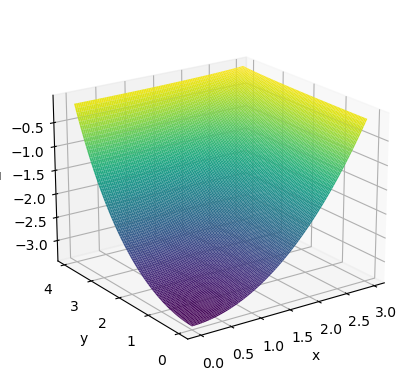

In [71]:
uu=u.reshape((Ny,Nx))

from mpl_toolkits import mplot3d
xx,yy = meshgrid(x, y)
ax = axes(projection='3d')
#ax.contour3D(X, Y, uubord, 50, cmap='binary')
ax.plot_surface(xx, yy, uu, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none');
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u');
ax.view_init(20, -125)

In [75]:
#f = lambda x,y : x*x*y*y*sy.sin(H-y)*sy.sin(x-L)
x,y = sy.symbols('x y')
u = x*x*y*y*sy.sin(H-y)*sy.sin(x-L)
f=-sy.diff(u, x, 2) - sy.diff(u, y, 2)
print(f)
dyu=sy.diff(u,y)
lambdify(f)
display(dyu.subs(y,0))
dxu=sy.diff(u,x)
display(dyu.subs(x,0))

-x**2*(y**2*sin(y - 4) - 4*y*cos(y - 4) - 2*sin(y - 4))*sin(x - 3) - y**2*(x**2*sin(x - 3) - 4*x*cos(x - 3) - 2*sin(x - 3))*sin(y - 4)


0

0

In [76]:
def f(x,y):
    return -x**2*(y**2*sin(y - 4) - 4*y*cos(y - 4) - 2*sin(y - 4))*sin(x - 3) - y**2*(x**2*sin(x - 3) - 4*x*cos(x - 3) - 2*sin(x - 3))*sin(y - 4)

In [ ]:
# La fonction pour calculer l'erreur
def erreur_Dirchlethd_Neumannbg(Nx, Ny, u, f, p):
    """
    N est le nombre de points de discrétisation
    u et f les fonctions passées en argumennt, on pourra en changer 
    en definissant d'autres fonctions
    p est l'entier pour la norme l^p
    """
    l = 1/(Nx+1)
    h = 1/(Ny+1)
    # construction du vecteur de discrétisation
    x=linspace(l,1-l,Nx)
    y=linspace(h,1-h,Ny)
    #construction du second membre du systeme
    F=f(x, y)